Starting K-Means...


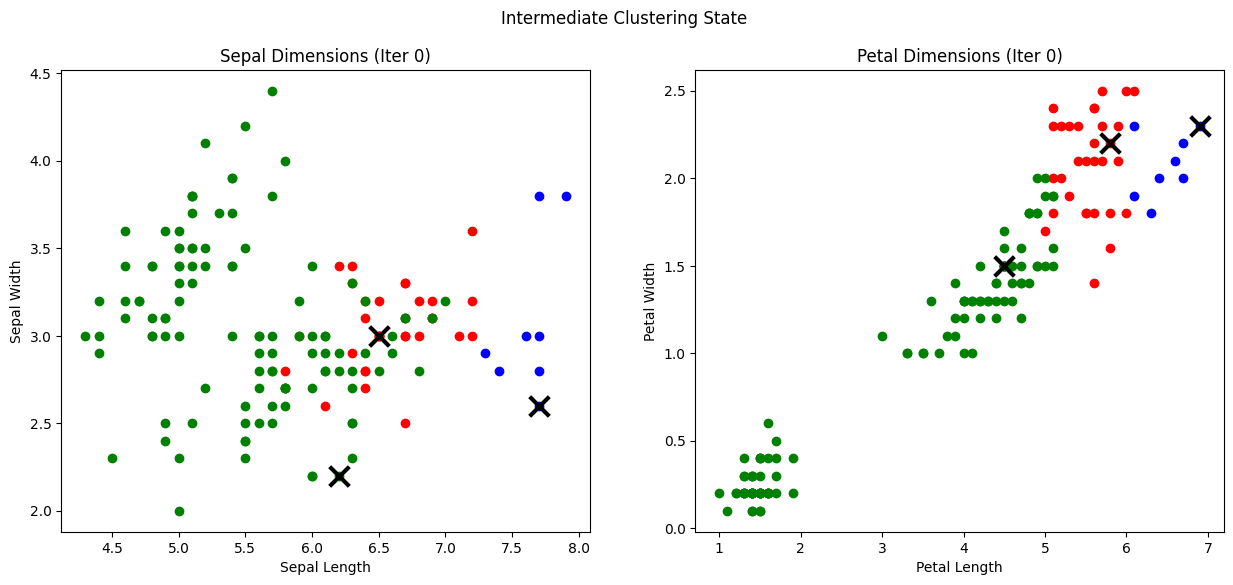

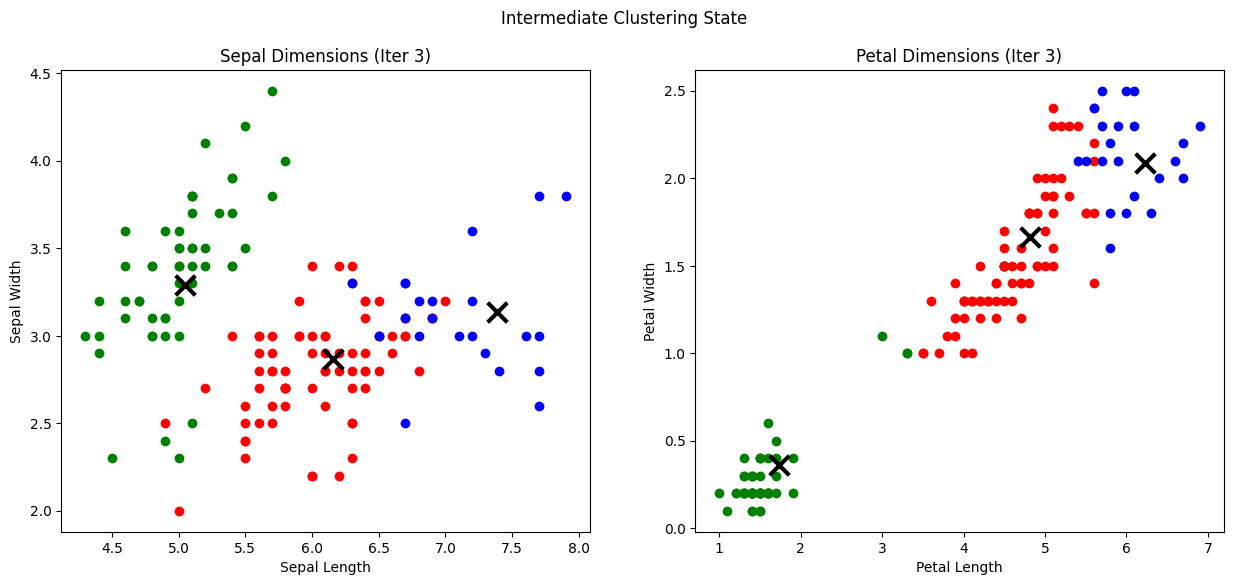

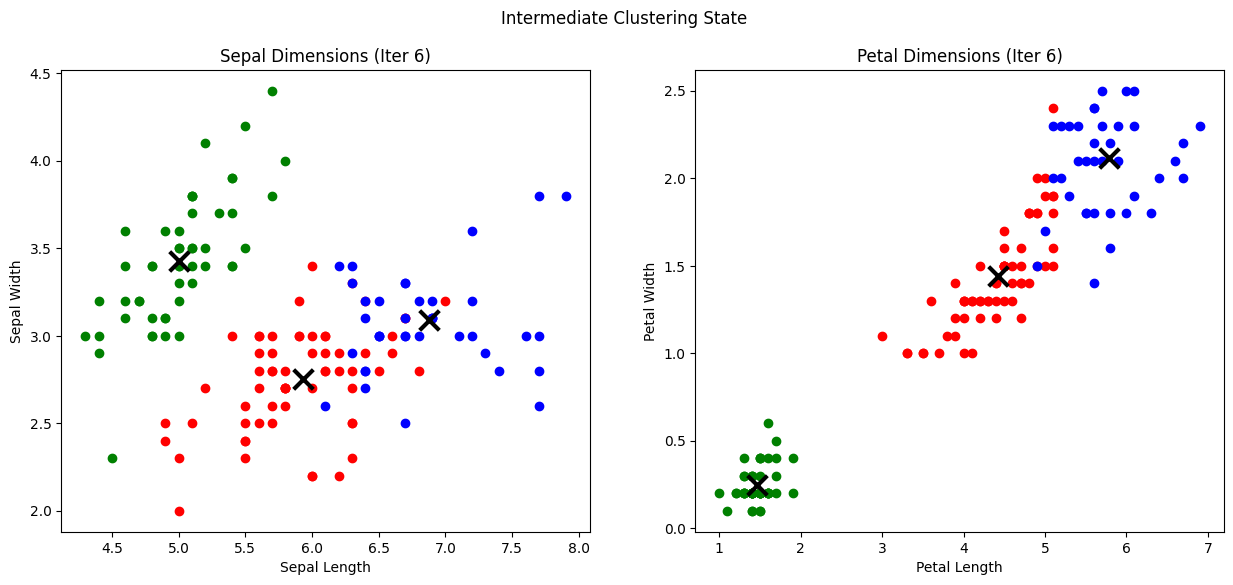

Converged at iteration 7


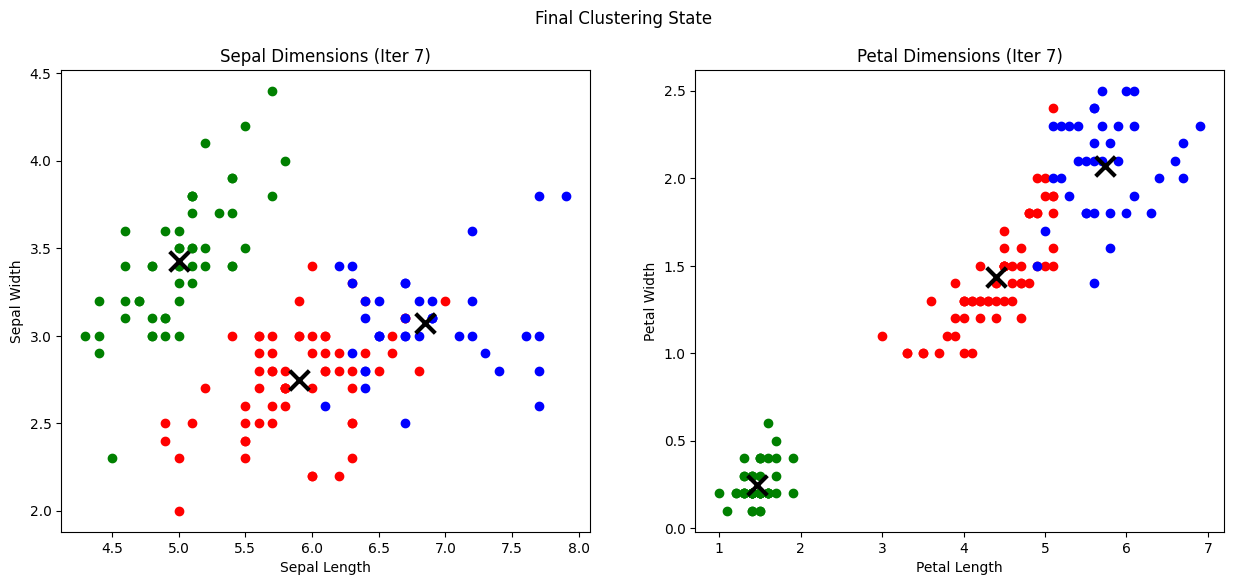

Generating 3D Plot...


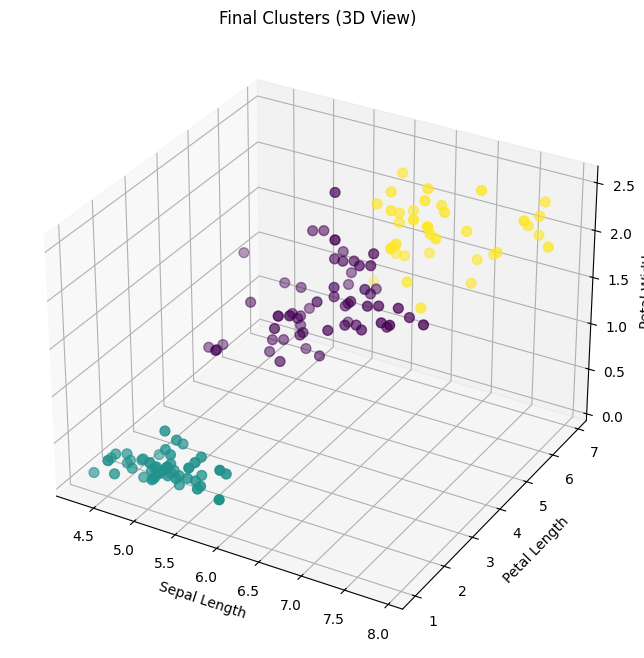

Generating Confusion Matrix...


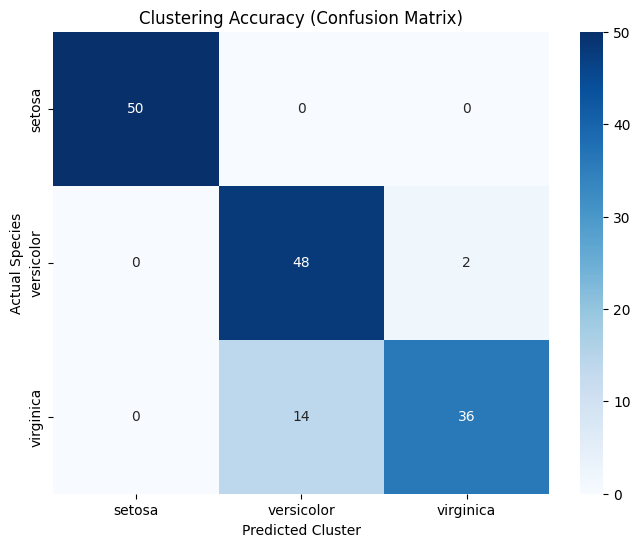

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class KMeansCustom:
    def __init__(self, k=3, max_iters=100, plot_steps=False):
        self.k = k
        self.max_iters = max_iters
        self.plot_steps = plot_steps
        self.clusters = [[] for _ in range(self.k)]
        self.centroids = []

    def predict(self, X):
        self.X = X
        self.n_samples, self.n_features = X.shape
        
        # 1. Initialize Centroids (Randomly select k samples)
        random_sample_idxs = np.random.choice(self.n_samples, self.k, replace=False)
        self.centroids = [self.X[idx] for idx in random_sample_idxs]

        # Optimization loop
        for i in range(self.max_iters):
            self.clusters = self._create_clusters(self.centroids)
            
            # Plot intermediate steps (First iteration and every 3rd to avoid clutter)
            if self.plot_steps and (i == 0 or i % 3 == 0):
                self.plot_2d(i, "Intermediate")

            centroids_old = self.centroids
            self.centroids = self._get_centroids(self.clusters)

            if self._is_converged(centroids_old, self.centroids):
                print(f"Converged at iteration {i}")
                break
                
        if self.plot_steps:
            self.plot_2d(i, "Final")
            
        return self._get_cluster_labels(self.clusters)

    def _get_cluster_labels(self, clusters):
        labels = np.empty(self.n_samples)
        for cluster_idx, cluster in enumerate(clusters):
            for sample_index in cluster:
                labels[sample_index] = cluster_idx
        return labels

    def _create_clusters(self, centroids):
        clusters = [[] for _ in range(self.k)]
        for idx, sample in enumerate(self.X):
            centroid_idx = self._closest_centroid(sample, centroids)
            clusters[centroid_idx].append(idx)
        return clusters

    def _closest_centroid(self, sample, centroids):
        distances = [np.linalg.norm(sample - point) for point in centroids]
        return np.argmin(distances)

    def _get_centroids(self, clusters):
        centroids = np.zeros((self.k, self.n_features))
        for cluster_idx, cluster in enumerate(clusters):
            cluster_mean = np.mean(self.X[cluster], axis=0)
            centroids[cluster_idx] = cluster_mean
        return centroids

    def _is_converged(self, centroids_old, centroids_new):
        distances = [np.linalg.norm(centroids_old[i] - centroids_new[i]) for i in range(self.k)]
        return sum(distances) == 0

    def plot_2d(self, iteration, title_prefix):
        # Create a figure with 2 subplots: Sepal View and Petal View
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        colors = ['r', 'g', 'b']
        
        # Plot 1: Sepal Length vs Sepal Width (Columns 0 and 1)
        for i, index in enumerate(self.clusters):
            points = self.X[index].T
            ax1.scatter(*points[:2], color=colors[i], label=f'Cluster {i}')
        for i, point in enumerate(self.centroids):
            ax1.scatter(*point[:2], marker="x", color="black", s=200, linewidth=3)
        ax1.set_title(f"Sepal Dimensions (Iter {iteration})")
        ax1.set_xlabel("Sepal Length")
        ax1.set_ylabel("Sepal Width")

        # Plot 2: Petal Length vs Petal Width (Columns 2 and 3)
        for i, index in enumerate(self.clusters):
            points = self.X[index].T
            ax2.scatter(points[2], points[3], color=colors[i], label=f'Cluster {i}')
        for i, point in enumerate(self.centroids):
            ax2.scatter(point[2], point[3], marker="x", color="black", s=200, linewidth=3)
        ax2.set_title(f"Petal Dimensions (Iter {iteration})")
        ax2.set_xlabel("Petal Length")
        ax2.set_ylabel("Petal Width")
        
        plt.suptitle(f"{title_prefix} Clustering State")
        plt.show()

# --- HELPER: 3D Visualization ---
def plot_3d(X, labels, title):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    # Using Sepal Length, Petal Length, Petal Width
    ax.scatter(X[:, 0], X[:, 2], X[:, 3], c=labels, cmap='viridis', s=50)
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Petal Length')
    ax.set_zlabel('Petal Width')
    ax.set_title(title)
    plt.show()

# --- HELPER: Confusion Matrix ---
def plot_confusion(y_true, y_pred, species_names):
    # Map predicted labels to most likely true labels to make the matrix readable
    from scipy.stats import mode
    labels = np.zeros_like(y_pred)
    for i in range(3):
        mask = (y_pred == i)
        if np.any(mask):
            labels[mask] = mode(y_true[mask], keepdims=True)[0][0]
    
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, labels)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=species_names, yticklabels=species_names)
    plt.ylabel('Actual Species')
    plt.xlabel('Predicted Cluster')
    plt.title('Clustering Accuracy (Confusion Matrix)')
    plt.show()

# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # 1. LOAD DATA
    # Adjust path if needed. Assumes iris.txt has 5 columns (4 numerical, 1 string label)
    # If using the standard sklearn dataset for testing:
    from sklearn.datasets import load_iris
    iris = load_iris()
    X = iris.data
    y_true = iris.target
    species_names = iris.target_names
    
    # 2. RUN K-MEANS
    print("Starting K-Means...")
    kmeans = KMeansCustom(k=3, max_iters=100, plot_steps=True)
    y_pred = kmeans.predict(X)

    # 3. FINAL VISUALIZATIONS
    print("Generating 3D Plot...")
    plot_3d(X, y_pred, "Final Clusters (3D View)")
    
    print("Generating Confusion Matrix...")
    plot_confusion(y_true, y_pred, species_names)